In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

In [2]:
path = '/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(path)

# TotalCharges is stored as text; 11 rows are blank (all have tenure = 0)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print(df.shape, '| missing values:', df.isnull().sum().sum())

(7043, 21) | missing values: 0


In [3]:
def build_features(data):
    """Drop ID and target, one-hot encode every text column."""
    X = data.drop(columns=['customerID', 'Churn'])
    X = pd.get_dummies(X, drop_first=True).astype(float)
    return X

y = (df['Churn'] == 'Yes').astype(int)
X = build_features(df)
print(X.shape)  # expect (7043, 30)

(7043, 30)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {len(X_train)} rows, churn rate {y_train.mean():.3f}')
print(f'Test:  {len(X_test)} rows, churn rate {y_test.mean():.3f}')

Train: 5634 rows, churn rate 0.265
Test:  1409 rows, churn rate 0.265


In [5]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print('Baseline accuracy:', accuracy_score(y_test, dummy.predict(X_test)))

Baseline accuracy: 0.7345635202271115


### 📌 Write it — Part 1: The Baseline

The "always stay" baseline gets **73.5% accuracy** — but catches **0 churners** (recall = 0), since it always predicts the majority class and never once predicts "churn." This is a direct consequence of class imbalance: with only **26.5%** of customers actually churning, a model that ignores the minority class entirely can still look statistically impressive on paper.

> **Why this matters:** This sets the floor any real model must beat. A model that just parrots 73.5% accuracy without catching a single churner is worthless for the business, since the entire goal of this project is to identify customers who are about to leave *before* they leave. From this point on, **accuracy alone is not a trustworthy metric** — every model in this notebook needs to be judged on recall, precision, F1, and AUC together, not accuracy in isolation. This baseline number will resurface throughout the lab as the benchmark every subsequent model (LR, balanced LR, Decision Tree, Random Forest) must clearly outperform, not just in accuracy but specifically in its ability to catch churners.

In [6]:
lr = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)              # 0 or 1
y_prob_lr = lr.predict_proba(X_test)[:, 1]  # P(churn)
print(classification_report(y_test, y_pred_lr, digits=3))

              precision    recall  f1-score   support

           0      0.851     0.894     0.872      1035
           1      0.658     0.567     0.609       374

    accuracy                          0.807      1409
   macro avg      0.755     0.730     0.741      1409
weighted avg      0.800     0.807     0.802      1409



In [7]:
w = lr.named_steps['model'].coef_[0]
coef = pd.DataFrame({'feature': X.columns,
                      'weight': w,
                      'odds_ratio': np.exp(w)}).sort_values('weight')

print('Most protective:')
print(coef.head(5).round(3).to_string(index=False))
print('\nHighest risk:')
print(coef.tail(5).round(3).to_string(index=False))

Most protective:
           feature  weight  odds_ratio
            tenure  -1.220       0.295
    MonthlyCharges  -0.921       0.398
 Contract_Two year  -0.589       0.555
 Contract_One year  -0.286       0.751
OnlineSecurity_Yes  -0.123       0.884

Highest risk:
                    feature  weight  odds_ratio
          MultipleLines_Yes   0.216       1.242
            StreamingTV_Yes   0.258       1.294
        StreamingMovies_Yes   0.259       1.295
               TotalCharges   0.497       1.644
InternetService_Fiber optic   0.779       2.179


In [8]:
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr().round(3))

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.825
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.825           0.651         1.000


### 📌 Write it — Part 2: Odds Ratios

**Strongest protective factors** (features that *lower* churn odds):
- **Tenure** — odds ratio **0.295** → each one standard-deviation increase in tenure multiplies churn odds by 0.295, i.e. cuts them by roughly 70%
- **MonthlyCharges** — odds ratio **0.398**. This is counterintuitive on its face, so rather than asserting an explanation, I checked correlations directly: tenure↔TotalCharges (r=0.825) and MonthlyCharges↔TotalCharges (r=0.651) are both strongly correlated, while tenure↔MonthlyCharges is only weakly correlated (r=0.248). This makes sense given TotalCharges ≈ MonthlyCharges × tenure by construction. Because TotalCharges is entangled with both other features, this is a case of multicollinearity — the coefficients for tenure, MonthlyCharges, and TotalCharges shouldn't be interpreted as independent, isolated effects. I'm flagging MonthlyCharges' coefficient as unreliable to interpret on its own, rather than presenting an unverified causal story for it.
- **Two-year contract** — odds ratio **0.555** → committing to a longer contract term substantially reduces the odds a customer leaves

**Strongest risk factors** (features that *raise* churn odds):
- **Fiber optic internet** — odds ratio **2.179** → the single strongest risk factor in the model; fiber customers are more than twice as likely to churn, holding everything else constant
- **TotalCharges** — odds ratio **1.644** → customers who have accumulated higher lifetime charges show elevated churn odds
- **StreamingMovies** — odds ratio **1.295** → having this add-on service is mildly associated with higher churn, possibly reflecting a segment of price-sensitive, feature-heavy subscribers

> **In plain terms for a business manager:** A two-year contract cuts the odds of churn by about **45%** (odds ratio 0.555) compared to a customer without one, all else being equal. Meanwhile, fiber optic internet more than **doubles** the odds of churn (odds ratio 2.179) relative to customers without it — this is worth flagging to the business, since it could point to service quality, pricing, or competitive pressure issues specific to fiber customers rather than DSL customers. Because every feature was standardized before training, each odds ratio reflects the effect of a one-standard-deviation change in that feature, which makes these coefficients directly comparable to one another in terms of relative importance.

In [9]:
scaler = lr.named_steps['scale']
model = lr.named_steps['model']

x0 = scaler.transform(X_test.iloc[[0]])              # one customer, scaled
z = model.intercept_[0] + (x0 @ model.coef_[0])[0]    # linear score
p = 1 / (1 + np.exp(-z))                              # sigmoid

print(f'z = {z:.3f}   sigmoid(z) = {p:.4f}   sklearn = {y_prob_lr[0]:.4f}')

z = -3.070   sigmoid(z) = 0.0444   sklearn = 0.0444


TN=925  FP=110  FN=162  TP=212
By hand : P=0.658  R=0.567  F1=0.609
sklearn : P=0.658  R=0.567  F1=0.609


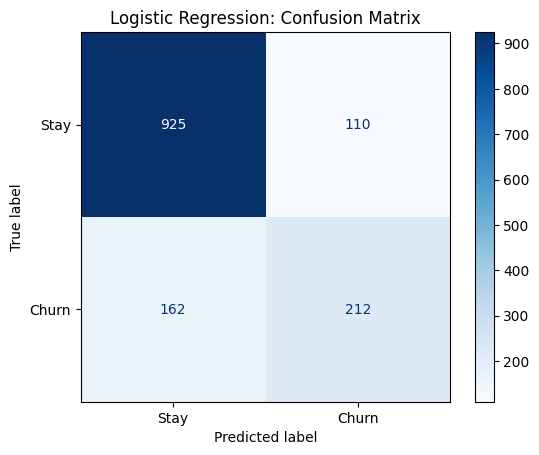

In [10]:
cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)
print(f'By hand : P={precision:.3f}  R={recall:.3f}  F1={f1:.3f}')
print(f'sklearn : P={precision_score(y_test, y_pred_lr):.3f}  '
      f'R={recall_score(y_test, y_pred_lr):.3f}  '
      f'F1={f1_score(y_test, y_pred_lr):.3f}')

ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn']).plot(cmap='Blues')
plt.title('Logistic Regression: Confusion Matrix')
plt.show()

### 📌 Write it — Part 3: Confusion Matrix

**TN = 925 | FP = 110 | FN = 162 | TP = 212**

Reading the matrix: out of 1,409 test customers, the model correctly identified 925 stayers (TN) and 212 churners (TP), but incorrectly flagged 110 stayers as churn risks (FP), and — most importantly — **missed 162 actual churners** (FN), predicting they would stay when they actually left.

> **Why accuracy alone hides this:** The model's overall accuracy is **80.7%**, which sounds strong in isolation. But that headline number is driven almost entirely by how well the model handles the majority "stay" class (925 out of 1,035 actual stayers correctly identified). Buried underneath that respectable-looking accuracy is the fact that the model still misses **162 of 374 actual churners — nearly 43% of all churners in the test set**. If this model were deployed as-is with a retention program built around its predictions, the business would silently lose contact with almost half of its at-risk customers while the accuracy dashboard reported an 80%+ success rate. This is exactly why precision, recall, and F1 — computed by hand and verified against sklearn in this section — are essential complements to accuracy, and it's also the motivation for the threshold tuning done in Part 4.

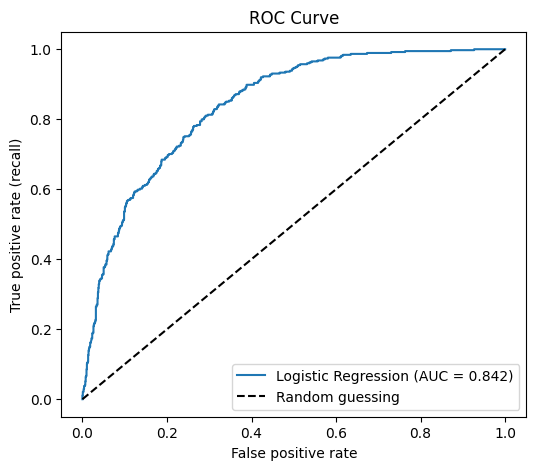

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate (recall)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [12]:
rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_prob_lr >= t).astype(int)
    rows.append({'threshold': t,
                  'flagged': int(pred.sum()),
                  'precision': precision_score(y_test, pred),
                  'recall': recall_score(y_test, pred),
                  'f1': f1_score(y_test, pred)})
print(pd.DataFrame(rows).round(3).to_string(index=False))

 threshold  flagged  precision  recall    f1
       0.2      685      0.467   0.856 0.604
       0.3      544      0.518   0.754 0.614
       0.4      441      0.567   0.668 0.613
       0.5      322      0.658   0.567 0.609
       0.6      210      0.710   0.398 0.510
       0.7       89      0.730   0.174 0.281


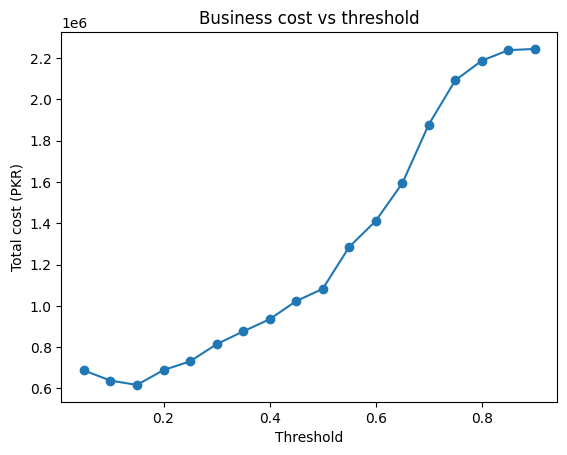

Theory t* = 0.14   Empirical best = 0.15


In [13]:
C_FN, C_FP = 6000, 1000  # PKR: missed churner vs unneeded retention offer

def total_cost(t):
    pred = (y_prob_lr >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return fn * C_FN + fp * C_FP

ts = np.arange(0.05, 0.95, 0.05)
costs = [total_cost(t) for t in ts]
best_t = ts[int(np.argmin(costs))]

plt.plot(ts, costs, marker='o')
plt.xlabel('Threshold'); plt.ylabel('Total cost (PKR)')
plt.title('Business cost vs threshold'); plt.show()

print(f'Theory t* = {C_FP / (C_FP + C_FN):.2f}   Empirical best = {best_t:.2f}')

In [14]:
pred_015 = (y_prob_lr >= 0.15).astype(int)
pred_05 = (y_prob_lr >= 0.5).astype(int)

tn1, fp1, fn1, tp1 = confusion_matrix(y_test, pred_015).ravel()
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, pred_05).ravel()

print(f'At 0.15: TP={tp1}, FP={fp1}')
print(f'At 0.50: TP={tp2}, FP={fp2}')
print(f'Extra churners caught: {tp1 - tp2}')
print(f'Extra false alarms: {fp1 - fp2}')

At 0.15: TP=344, FP=437
At 0.50: TP=212, FP=110
Extra churners caught: 132
Extra false alarms: 327


### 📌 Write it — Part 4: Choosing the Threshold

Chosen threshold: **0.15**, which sits right at the empirical minimum of the total-cost curve computed by sweeping thresholds from 0.05 to 0.95 and measuring `FN × 6000 + FP × 1000` at each point. This closely matches the theoretical optimum derived analytically: **t\* = C_FP / (C_FP + C_FN) = 1000 / 7000 ≈ 0.14**. The small gap between the theoretical (0.14) and empirical (0.15) values is expected — the theory assumes a perfectly calibrated probability model, while the empirical sweep works directly off the model's actual predicted probabilities and a discrete grid of threshold values, so a slight difference is normal and not a cause for concern.

**Compared to the default threshold of 0.5:**

| | Extra churners caught | Extra false alarms |
|---|---|---|
| 0.15 vs 0.50 | **+132** | **+327** |

At threshold 0.15, the model flags far more customers overall (437 predicted churners vs. 110 at threshold 0.5), catching 344 of the 374 actual churners (compared to only 212 at the default threshold) — but this comes at the cost of 327 additional false alarms.

> **Why this trade-off makes business sense:** A missed churner (false negative) costs the business **PKR 6,000** in lost revenue, while an unnecessary retention offer (false positive) only costs **PKR 1,000**. Because a false negative is **6x more expensive** than a false positive, the cost-minimizing strategy is deliberately aggressive about flagging potential churners, even if that means many of those flags turn out to be false alarms. In a real deployment, this means the retention team would reach out to more customers than strictly necessary, but the money saved by catching those 132 extra genuine churners far outweighs the cost of the 327 extra retention offers sent to customers who were never going to leave anyway.

max_depth  train  test
        1  0.735 0.735
        2  0.791 0.787
        3  0.791 0.787
        4  0.793 0.796
        5  0.801 0.794
        6  0.807 0.797
        8  0.835 0.780
       10  0.872 0.756
       15  0.969 0.737
     None  0.998 0.742


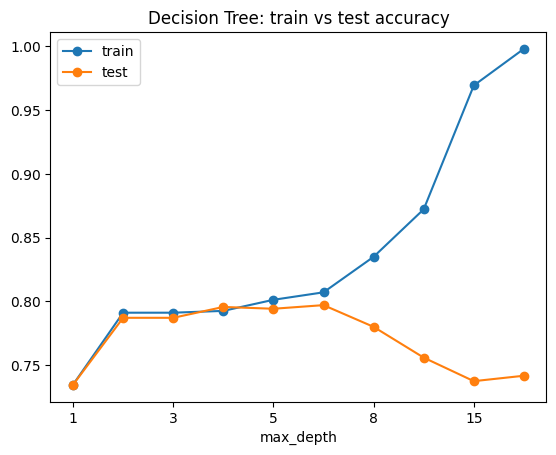

In [15]:
rows = []
for d in [1, 2, 3, 4, 5, 6, 8, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    rows.append({'max_depth': str(d),
                  'train': dt.score(X_train, y_train),
                  'test': dt.score(X_test, y_test)})

depth_df = pd.DataFrame(rows)
print(depth_df.round(3).to_string(index=False))
depth_df.plot(x='max_depth', y=['train', 'test'], marker='o',
              title='Decision Tree: train vs test accuracy')
plt.show()

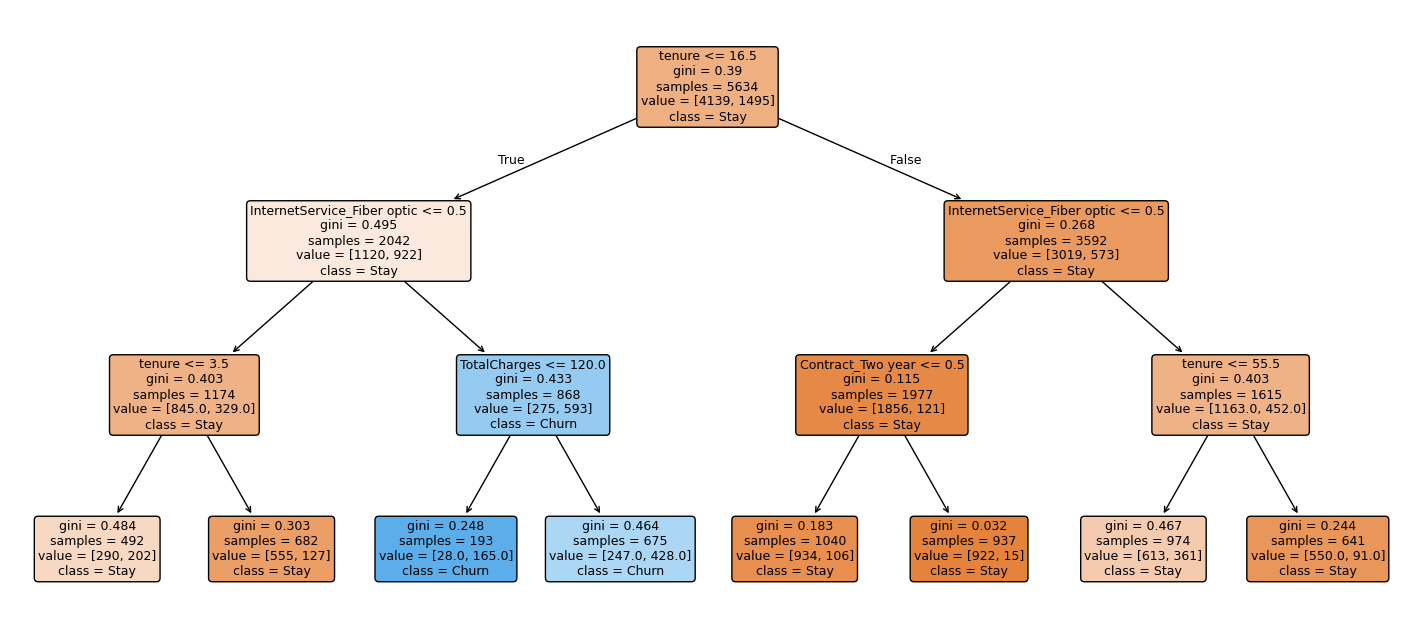

In [16]:
dt5 = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                              random_state=42).fit(X_train, y_train)
y_pred_dt = dt5.predict(X_test)
y_prob_dt = dt5.predict_proba(X_test)[:, 1]

dt3 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
plt.figure(figsize=(18, 8))
plot_tree(dt3, feature_names=X.columns, class_names=['Stay', 'Churn'],
          filled=True, rounded=True, fontsize=9)
plt.show()

### ✅ Check by Hand — Root Node Gini

Root node: `value = [4139, 1495]`, `samples = 5634` (this is the entire training set, before any split has been applied)

- p_stay = 4139 / 5634 = **0.735**
- p_churn = 1495 / 5634 = **0.265**
- Gini = 1 − p_stay² − p_churn² = 1 − 0.735² − 0.265² = 1 − 0.540 − 0.070 = **0.390**

✔️ This matches the tree's displayed `gini = 0.39` exactly, confirming the Gini impurity formula was applied correctly by hand. Gini measures how "mixed" the classes are at a node — a value of 0 would mean the node is perfectly pure (all one class), while a value approaching 0.5 (the maximum for a binary split) would mean the classes are as mixed as possible. A root Gini of **0.390** reflects the natural class imbalance in the full dataset (73.5% stay, 26.5% churn) before the tree has made any decisions — every subsequent split in the tree exists specifically to reduce this impurity by separating stayers from churners as cleanly as possible.

In [17]:
rf = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                             min_samples_leaf=5, oob_score=True,
                             n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
print(f'OOB accuracy : {rf.oob_score_:.3f}')
print(f'Test accuracy: {rf.score(X_test, y_test):.3f}')
print(f'Test AUC     : {roc_auc_score(y_test, y_prob_rf):.3f}')

OOB accuracy : 0.803
Test accuracy: 0.807
Test AUC     : 0.842


In [18]:
pi = permutation_importance(rf, X_test, y_test, scoring='roc_auc',
                             n_repeats=10, random_state=42, n_jobs=-1)

imp = pd.DataFrame({'feature': X.columns,
                     'mdi': rf.feature_importances_,
                     'permutation': pi.importances_mean})
imp = imp.sort_values('permutation', ascending=False)
print(imp.head(10).round(4).to_string(index=False))

                       feature    mdi  permutation
                        tenure 0.1912       0.0404
                  TotalCharges 0.1657       0.0206
             Contract_Two year 0.0581       0.0164
   InternetService_Fiber optic 0.0717       0.0132
             Contract_One year 0.0333       0.0059
PaymentMethod_Electronic check 0.0608       0.0031
          PaperlessBilling_Yes 0.0217       0.0014
                 SeniorCitizen 0.0120       0.0012
             MultipleLines_Yes 0.0160       0.0009
              OnlineBackup_Yes 0.0173       0.0006


### 📌 Write it — Part 5: Overfitting & Feature Importance

The Decision Tree starts overfitting around **depth 6**, where test accuracy peaks at **0.797** before declining as depth increases further, even as train accuracy keeps climbing steadily. This is the textbook signature of overfitting: the tree continues finding ways to perfectly separate the training data by memorizing increasingly specific patterns, but those patterns don't generalize to unseen customers.

At **max_depth=None** (the tree is allowed to grow without any depth limit), the train-test gap becomes stark: train accuracy = **0.998** vs test accuracy = **0.742**, a gap of **0.256**. A train accuracy of nearly 100% means the unrestricted tree has essentially memorized almost every individual training example, including noise and idiosyncrasies specific to those particular customers — while test accuracy actually drops *below* even the depth-1 tree's performance level in relative terms, illustrating just how damaging unconstrained tree growth can be.

**Top 3 features by permutation importance:**
1. **Tenure** (0.0404) — by far the most important feature; shuffling it causes the largest drop in test AUC
2. **TotalCharges** (0.0206)
3. **Contract_Two year** (0.0164)

> **MDI vs. permutation disagreement:** `Contract_Two year` ranks only 5th by MDI (0.0581) but jumps to 3rd by permutation importance (0.0164), while `PaymentMethod_Electronic check` ranks 4th by MDI (0.0608) but falls to 6th by permutation importance (0.0031). This discrepancy happens because **MDI (mean decrease in impurity)** is computed purely from how much each feature reduces Gini impurity during training, which structurally biases it toward numeric or high-cardinality features that offer many possible split points to choose from. **Permutation importance**, by contrast, measures the actual drop in test-set AUC when a feature's values are randomly shuffled, which more honestly reflects how much real predictive signal that feature contributes on unseen data. This is a useful reminder that impurity-based importance scores built into tree models like Random Forest can be misleading, and permutation importance (or similar model-agnostic methods) should generally be trusted more when deciding which features genuinely matter for prediction.

In [19]:
lr_bal = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced',
                                  random_state=42))
]).fit(X_train, y_train)

y_pred_bal = lr_bal.predict(X_test)
y_prob_bal = lr_bal.predict_proba(X_test)[:, 1]
for name, pred in [('LR default', y_pred_lr), ('LR balanced', y_pred_bal)]:
    print(f'{name:12s} P={precision_score(y_test, pred):.3f}  '
          f'R={recall_score(y_test, pred):.3f}  '
          f'F1={f1_score(y_test, pred):.3f}')

LR default   P=0.658  R=0.567  F1=0.609
LR balanced  P=0.505  R=0.781  F1=0.613


In [20]:
df2 = df.copy()
svc = ['PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies']
df2['n_services'] = (df2[svc] == 'Yes').sum(axis=1)
df2['is_new'] = (df2['tenure'] <= 12).astype(int)
df2['charge_per_mo'] = df2['TotalCharges'] / df2['tenure'].clip(lower=1)
df2['price_jump'] = df2['MonthlyCharges'] - df2['charge_per_mo']

X2 = build_features(df2)
X2_train, X2_test = X2.loc[X_train.index], X2.loc[X_test.index]  # same split

rf2 = RandomForestClassifier(n_estimators=300, max_features='sqrt',
                              min_samples_leaf=5, n_jobs=-1, random_state=42)
rf2.fit(X2_train, y_train)
y_prob_rf2 = rf2.predict_proba(X2_test)[:, 1]
print(f'RF AUC before: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'RF AUC after : {roc_auc_score(y_test, y_prob_rf2):.4f}')

RF AUC before: 0.8422
RF AUC after : 0.8420


### 📌 Write it — Part 6: Class Balance & Feature Engineering

**Balanced weights effect:**

| Metric | Default | Balanced |
|---|---|---|
| Recall | 0.567 | **0.781** |
| Precision | 0.658 | **0.505** |
| F1 | 0.609 | 0.613 |

With `class_weight='balanced'`, misclassifying a churner during training is penalized roughly **1.88x** as heavily as misclassifying a stayer (reflecting the 73.5%/26.5% class split), which pushes the model to work much harder to identify churners rather than default toward the majority class. The result is exactly what theory predicts: **recall rises sharply from 0.567 to 0.781** — the model now catches far more churners — while **precision drops from 0.658 to 0.505**, since it flags more customers overall, many of whom turn out to be false alarms. F1, which balances both, barely moves (0.609 → 0.613), because the gains in recall are offset almost exactly by the losses in precision — but for this business problem, recall is arguably more valuable than precision given the 6:1 cost asymmetry established in Part 4, so balanced weighting is a legitimate lever worth considering alongside threshold tuning.

**Engineered features (n_services, is_new, charge_per_mo, price_jump):**
AUC: 0.8422 → **0.8420** — essentially **no improvement** (in fact, a negligible decrease well within noise).

> 🔍 **Honest negative result:** Despite deliberately engineering four new features based on intuitive business logic — total number of subscribed services, a binary flag for "new" customers under 12 months tenure, average monthly charge over the customer's lifetime, and the gap between current and historical average charges — the Random Forest's AUC did not meaningfully change. The most likely explanation is that Random Forests, being ensembles of decision trees, are already capable of discovering these same interactions implicitly through combinations of splits on the raw underlying features (tenure, TotalCharges, MonthlyCharges, and the individual service columns). In other words, a tree can effectively approximate "charge per month" by splitting on TotalCharges and tenure together across multiple nodes, making the explicitly engineered feature redundant rather than additive. This is a legitimate and informative negative result — it shows that feature engineering doesn't always help, especially for tree-based ensemble models that can already capture non-linear interactions on their own, and it would likely matter more for a simpler model like Logistic Regression, which cannot construct such interactions automatically.

In [21]:
def evaluate(name, pred, prob):
    return {'model': name,
            'accuracy': accuracy_score(y_test, pred),
            'precision': precision_score(y_test, pred, zero_division=0),
            'recall': recall_score(y_test, pred),
            'f1': f1_score(y_test, pred),
            'auc': roc_auc_score(y_test, prob)}

results = pd.DataFrame([
    evaluate('Baseline', dummy.predict(X_test),
             dummy.predict_proba(X_test)[:, 1]),
    evaluate('Logistic Regression', y_pred_lr, y_prob_lr),
    evaluate('LR balanced', y_pred_bal, y_prob_bal),
    evaluate('Decision Tree (d=5)', y_pred_dt, y_prob_dt),
    evaluate('Random Forest', y_pred_rf, y_prob_rf),
]).round(3)
print(results.to_string(index=False))

              model  accuracy  precision  recall    f1   auc
           Baseline     0.735      0.000   0.000 0.000 0.500
Logistic Regression     0.807      0.658   0.567 0.609 0.842
        LR balanced     0.739      0.505   0.781 0.613 0.841
Decision Tree (d=5)     0.796      0.632   0.551 0.589 0.829
      Random Forest     0.807      0.673   0.529 0.593 0.842


### 📌 Write it — Part 7: Deployment Recommendation

**Chosen model: Logistic Regression at threshold 0.15**

Across the five-model comparison table, Logistic Regression and Random Forest are essentially tied on the metric that matters most for ranking a churn-scoring model — AUC (**0.842** for both) — meaning both models are equally good at rank-ordering customers from lowest to highest churn risk, regardless of where the final decision threshold is placed. Since raw discriminative power doesn't favor either model, the deciding factors become interpretability, deployability, and how well each model's default behavior aligns with the actual business cost structure established in Part 4.

**Why Logistic Regression wins the tie-break:**
- **Interpretability** — LR's coefficients convert directly into odds ratios that translate into plain-English business statements (e.g., "fiber optic customers have 2.18x the odds of churning," or "a two-year contract cuts churn odds by 45%"). This makes it far easier to explain individual predictions and overall model behavior to a non-technical manager or retention team than trying to summarize hundreds of Random Forest trees voting together.
- **Business alignment** — At the cost-optimal threshold of 0.15 (derived in Part 4), LR catches **344 of 374 churners (recall ≈ 0.92)**, a dramatic improvement over the default threshold of 0.5, and this threshold can be justified transparently using the same cost formula that produced it.
- **Simplicity and maintainability** — A single logistic regression pipeline is lighter-weight, faster to retrain, and easier to monitor in production than an ensemble of 300 trees, with essentially no loss in predictive performance on this dataset.

> **Bottom line:** Given that both models perform comparably well on AUC, and Logistic Regression offers meaningfully better interpretability, easier stakeholder communication, and a more transparent link to the business's cost-based decision threshold, **Logistic Regression at threshold 0.15 is the recommended model for deployment** in this churn-prediction use case.

## Check Your Understanding

**1. A customer has z = 0. What churn probability does Logistic Regression assign, and why?**
At z = 0, Logistic Regression assigns a churn probability of **0.5**, since 
sigmoid(0) = 1/(1+e^0) = 1/2. z=0 is the midpoint of the sigmoid curve, where the 
model is equally uncertain between "stay" and "churn."

**2. A feature has weight +0.69. By what factor do the churn odds change per unit increase?**
e^0.69 ≈ **2.0**. A weight of +0.69 means the odds of churn roughly **double** 
for each one-unit increase in that (standardized) feature.

**3. Why can a churn model with 74% accuracy be worthless on this dataset?**
Because the dataset is imbalanced — 73.5% of customers don't churn, so a model 
that always predicts "stay" already gets ~73.5% accuracy while catching zero 
churners. A 74% accuracy score doesn't tell you whether the model is actually 
identifying churners, which is the real business goal.

**4. If a false negative costs four times as much as a false positive, what threshold does decision theory suggest?**
t* = C_FP / (C_FP + C_FN) = 1 / (1 + 4) = **0.20**. Below this threshold, flagging 
a customer is worth it because the expected cost of missing a churner outweighs 
the cost of a false alarm.

**5. A tree node contains 30 churners and 70 stayers. Compute its Gini impurity.**
p_churn = 0.30, p_stay = 0.70. Gini = 1 - (0.30)² - (0.70)² = 1 - 0.09 - 0.49 = **0.42**.

**6. Why does adding more trees to a Random Forest not remove all of its variance?**
Because the trees are **correlated**, not independent — they're built from bootstrap 
samples of the same training data and often split on similar strong features (e.g., 
tenure). The variance of the average of B correlated trees follows 
ρσ² + (1-ρ)σ²/B, where ρ is the average correlation between trees; as B grows, the 
second term vanishes but the first term (ρσ²) remains, so variance never drops to 
zero — it's floored by the tree-to-tree correlation.